In [ ]:
# Basic libraries
import pandas as pd
import numpy as np

# Model and metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load cleaned dataset
df = pd.read_csv("/content/diabetes_final.csv")

# Show info
print("Dataset Loaded Successfully")
print("Shape:", df.shape)
df.head()


Dataset Loaded Successfully
Shape: (58908, 31)


,Diabetes_binary,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,GenHlth,...,AgeRange_32-38,AgeRange_39-45,AgeRange_46-52,AgeRange_53-59,AgeRange_60-66,AgeRange_67-73,AgeRange_74-80,AgeRange_81-87,AgeRange_88-94,AgeRange_95-101
0,0.0,1.0,0.0,-0.587825,0.0,0.0,0.0,1.0,0.0,0.50,...,0,1,0,0,0,0,0,0,0,0
1,0.0,1.0,1.0,-0.587825,1.0,1.0,0.0,0.0,0.0,0.50,...,0,0,0,0,0,0,0,0,0,1
2,0.0,0.0,0.0,-0.587825,0.0,0.0,0.0,1.0,0.0,0.00,...,0,0,0,0,0,0,0,0,0,0
3,0.0,1.0,1.0,-0.319523,1.0,0.0,0.0,1.0,0.0,0.50,...,0,0,0,0,0,0,0,0,1,0
4,0.0,0.0,0.0,-0.185372,1.0,0.0,0.0,1.0,0.0,0.25,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
# Separate features (inputs) and target (output)
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']


In [ ]:
# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (47126, 30)
Testing Data Shape: (11782, 30)


In [ ]:
# Create and train a Decision Tree model
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Predict on test data
y_pred = dt_model.predict(X_test)

# Evaluate
print("Decision Tree Model Results (Before Tuning)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Decision Tree Model Results (Before Tuning)
Accuracy: 0.7143948395858088

Confusion Matrix:
 [[3388 2109]
 [1256 5029]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.73      0.62      0.67      5497
         1.0       0.70      0.80      0.75      6285

    accuracy                           0.71     11782
   macro avg       0.72      0.71      0.71     11782
weighted avg       0.72      0.71      0.71     11782



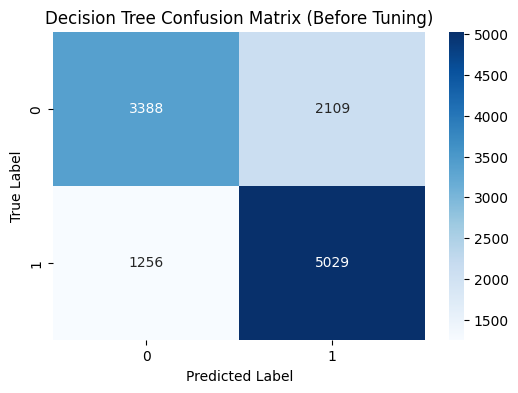

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix (Before Tuning)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()



In [ ]:
# Define model and parameter grid
dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    'criterion': ['gini', 'entropy'],          # split quality measure
    'max_depth': [3, 5, 7, 9, 12, 15],         # tree depth
    'min_samples_split': [2, 5, 10],           # minimum samples to split a node
    'min_samples_leaf': [1, 2, 4]              # minimum samples per leaf
}

# Use GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit the model
grid_search.fit(X_train, y_train)

# Print best parameters and accuracy
print("Best Parameters Found:", grid_search.best_params_)
print(" Best Cross-Validation Accuracy:", grid_search.best_score_)


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters Found: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2}
 Best Cross-Validation Accuracy: 0.7211093172504969


In [ ]:
# Compare training vs testing accuracy
train_acc = accuracy_score(y_train, best_model.predict(X_train))
test_acc = accuracy_score(y_test, best_model.predict(X_test))

print(f"Training Accuracy: {train_acc*100:.2f}%")
print(f"Testing Accuracy:  {test_acc*100:.2f}%")

if train_acc - test_acc > 0.1:
    print(" Model might be overfitting (too good on training data).")
else:
    print("Model is balanced, no major overfitting detected.")

Training Accuracy: 72.96%
Testing Accuracy:  71.91%
Model is balanced, no major overfitting detected.



 Accuracy Comparison
Before Tuning Accuracy: 71.44%
After Tuning Accuracy:  71.91%
 Improvement: 0.47%


/tmp/ipython-input-1924394454.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Before Tuning', 'After Tuning'], y=[base_acc, best_acc], palette='viridis')


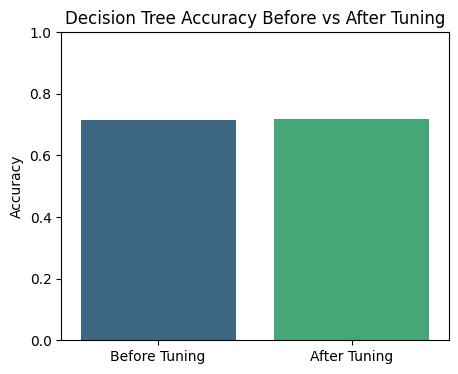

In [ ]:
# Calculate base and tuned accuracies
base_acc = accuracy_score(y_test, y_pred)
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
best_acc = accuracy_score(y_test, y_pred_best)

print("\n Accuracy Comparison")
print(f"Before Tuning Accuracy: {base_acc*100:.2f}%")
print(f"After Tuning Accuracy:  {best_acc*100:.2f}%")
print(f" Improvement: {(best_acc - base_acc)*100:.2f}%")

# Bar chart visualization
plt.figure(figsize=(5,4))
sns.barplot(x=['Before Tuning', 'After Tuning'], y=[base_acc, best_acc], palette='viridis')
plt.title("Decision Tree Accuracy Before vs After Tuning")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

In [ ]:
base_acc = accuracy_score(y_test, y_pred)
best_acc = accuracy_score(y_test, y_pred_best)

print("Accuracy Before Tuning:", round(base_acc * 100, 2), "%")
print("Accuracy After Tuning:", round(best_acc * 100, 2), "%")
print("🔺 Accuracy Improvement:", round((best_acc - base_acc) * 100, 2), "%")

Accuracy Before Tuning: 71.44 %
Accuracy After Tuning: 71.91 %
Accuracy Improvement: 0.47 %


/tmp/ipython-input-4077061645.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='mako')


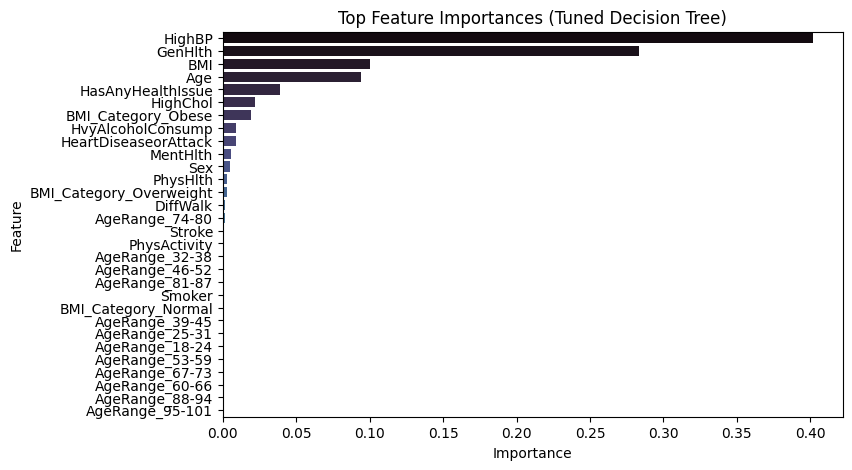

In [ ]:
# Get feature importances
importances = best_model.feature_importances_
features = X.columns

# Create DataFrame for visualization
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='mako')
plt.title("Top Feature Importances (Tuned Decision Tree)")
plt.show()
